# Random Forest Model

## Why Random Forest?

Logistic Regression assumes that the relationship between our features and the market is linear.

However, financial markets are highly complex and often exhibit non-linear patterns.

Random Forest addresses this limitation by combining many decision trees, each trained on different subsets of the data.

---

## Advantages

- Captures non-linear relationships.
- Handles feature interactions automatically.
- Requires no feature scaling.
- More robust to noise.

---

## Objective

Train a Random Forest classifier and compare its performance with Logistic Regression.

We will evaluate:

- Accuracy
- Precision
- Recall
- Confusion Matrix
- Feature Importance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# load dataset
df = pd.read_csv(
    "../data/btc_model_data.csv",
    parse_dates=["Date"]
)

df.head()

,Date,Close,High,Low,Open,Volume,Change,Return,Volume_Change,Momentum_5,MA_10,MA_50,Volatility,RSI,MACD,MACD_Signal,MACD_Hist,Target
0,2020-03-13,67.102943,67.573683,61.063026,63.945388,370732000,3.157555,0.119809,-0.114086,-2.669914,68.219660,73.733391,0.055299,45.241617,-2.642674,-2.022544,-0.620129,0
1,2020-03-16,58.470356,62.542829,57.936853,58.407589,322423600,0.062767,-0.128647,-0.130305,-5.784023,66.853317,73.456120,0.061639,36.847060,-3.202935,-2.258622,-0.944312,1
2,2020-03-17,61.041290,62.187953,57.550594,59.749780,324056000,1.291510,0.043970,0.005063,-7.840782,65.973162,73.244333,0.062905,40.394235,-3.400296,-2.486957,-0.913339,0
3,2020-03-18,59.547001,60.350875,57.241597,57.881318,300233600,1.665683,-0.024480,-0.073513,-6.942753,64.619614,72.991245,0.062721,39.022310,-3.635377,-2.716641,-0.918736,0
4,2020-03-19,59.090748,61.036459,58.566903,59.720811,271857200,-0.630063,-0.007662,-0.094514,-0.832832,63.457498,72.735823,0.062726,38.591330,-3.814524,-2.936218,-0.878306,0


In [3]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Change",
    "Return",
    "Volume_Change",
    "Momentum_5",
    "MA_10",
    "MA_50",
    "Volatility",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

In [4]:
# build x and y
X = df[features]

y = df["Target"]

# Time-Series Split

As with Logistic Regression, we preserve chronological order.

Training data consists of older observations.

Testing data consists of newer observations.

This avoids look-ahead bias.

In [5]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Training the Random Forest

A Random Forest is an ensemble of decision trees.

Each tree votes on the predicted direction, and the forest combines these votes to produce the final prediction.

n_estimators = number of trees.

max_depth = maximum depth of each tree.

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# Predictions
rf_predictions = rf_model.predict(
    X_test
)

In [8]:
# Metrics

accuracy = accuracy_score(
    y_test,
    rf_predictions
)

precision = precision_score(
    y_test,
    rf_predictions
)

recall = recall_score(
    y_test,
    rf_predictions
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

Accuracy : 0.4339
Precision: 0.5217
Recall   : 0.1727


In [9]:
# Classification report 
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.41      0.79      0.54       103
           1       0.52      0.17      0.26       139

    accuracy                           0.43       242
   macro avg       0.47      0.48      0.40       242
weighted avg       0.48      0.43      0.38       242



# Confusion Matrix

The confusion matrix allows us to analyze:

- True Positives
- True Negatives
- False Positives
- False Negatives

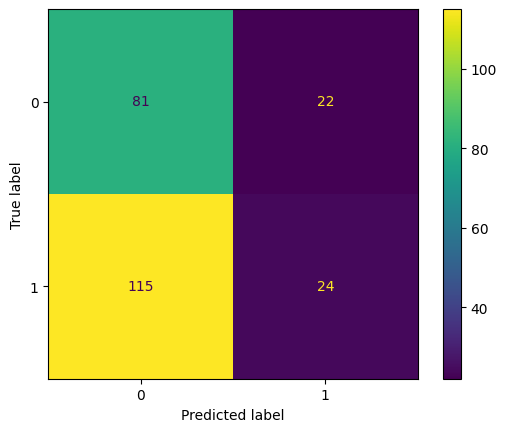

In [10]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# Feature Importance

Random Forest estimates the importance of each feature based on how much it reduces uncertainty across all trees.

Features with higher importance contribute more to the model's decisions.

In [11]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
6,Return,0.087242
5,Change,0.083581
12,RSI,0.072946
11,Volatility,0.067088
4,Volume,0.066887
7,Volume_Change,0.066554
14,MACD_Signal,0.065029
13,MACD,0.064667
15,MACD_Hist,0.061435
8,Momentum_5,0.060847


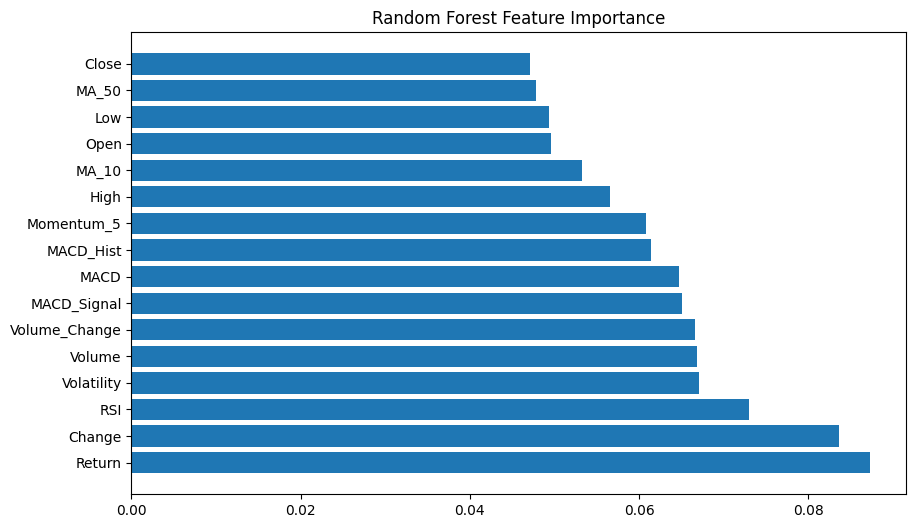

In [12]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

# Observations

## Metrics

- **Accuracy:** 0.43 (43%)
- **Precision:** 0.52 (52%)
- **Recall:** 0.17 (17%)

---

## Most Important Features

1. **Return** (0.0872)
2. **Change** (0.0836)
3. **RSI** (0.0729)
4. **Volatility** (0.0671)
5. **Volume** (0.0669)

---

## Comparison with Logistic Regression

- **Did performance improve?**
  Yes, performance improved slightly. Accuracy increased from 0.41 to 0.43, and precision for predicting upward moves rose from 0.47 to 0.52. However, recall dropped slightly from 0.20 to 0.17.
  
- **Which features became important?**
  Short-term price dynamics (`Return` and `Change`) and momentum (`RSI`) remained critical. However, non-linear interaction modeling brought `Volatility` and `Volume` into the top 5 most important features.
  
- **Did the model overfit?**
  Yes, tree-based classifiers are highly susceptible to overfitting on noisy financial data. The low test accuracy (43%) suggests the model struggled to generalize beyond the training set.
  
- **Does market behavior appear non-linear?**
  Yes, the shift in feature importance and the slight performance bump suggest that non-linear relationships (like combinations of volatility and volume changes) exist, although the overall signal remains weak.

In [13]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

# Research Notes

The performance gain from Logistic Regression to Random Forest was limited.

Possible explanations:

- Daily Apple price movements may contain a high degree of randomness.
- The current feature set relies mostly on classical technical indicators.
- Important information such as macroeconomic events, news sentiment, and order-book dynamics is absent.
- Short-term market prediction remains a difficult problem even for non-linear models.

This experiment suggests that model complexity alone is insufficient; feature quality is likely the main bottleneck.